## Functions 

In [ ]:
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import camera
import cv2
import numpy as np
import pandas as pd
from ultralytics import YOLO
from datetime import datetime
import time


# -- CONSTANTS -- 

# The objects the object_detection_model looks for. 
CLASS_NAMES = ["bear", "cyclist", "fox", "reindeer", "robot", "santa"]

# Insert the path of the model used here.
MODEL_PATH  = "../Models/yolo_detect/best.pt"

# The level of certainty before considering a predicted object as one of the CLASS_NAMES.
THRESHOLD   = 0.3

# -- FUNCTIONS -- 
def build_segments(df, class_names):
    """
    Creates a segmented version of a dataframe suitable for a Gantt Chart.

    df(param): The dataframe, which should have timestamps and the classes.
    class_names(param): The class names which should match the df parameter in column length.
    """
    segments = []

    for cls in class_names:
        active = False
        start = None

        for i in range(len(df)):
            val = df.iloc[i][cls]

            if val == 1 and not active:
                active = True
                start = i

            elif val == 0 and active:
                segments.append({
                    "class": cls,
                    "start": start,
                    "end": i
                })
                active = False

        if active:
            segments.append({
                "class": cls,
                "start": start,
                "end": len(df)
            })

    return segments


def gantt_show(segments):
    """
    Creates the Gantt plot illustration using matplotlib.pyplot. 
    segments(param): The segmented dataframe created from the build_segments() function.
    """
    fig, ax = plt.subplots(figsize=(10, 4), dpi=100)

    # Map each class to a y position
    class_to_y = {cls: i for i, cls in enumerate(CLASS_NAMES)}

    for seg in segments:
        ax.barh(
            y=class_to_y[seg["class"]],
            width=seg["end"] - seg["start"],
            left=seg["start"]
        )

    # Sets the labels, ticks, and titles. 
    ax.set_yticks(list(class_to_y.values()))
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Frame")
    ax.set_ylabel("Class")
    ax.set_title("Detection Timeline")

    # Show frame
    plt.tight_layout()
    plt.show()


def collect_frames():
    """
    Uses the camera to generate a number of frames (20 in this case).
    Returns frames and timestamps.
    """
    
    camera.start()
    frames = []
    timestamps = []

    print("------------------------------")
    print("Starting to collect frames...")    

    try:
        for num in range(20):
            frame = camera.get_latest_frame()
            if frame is not None:
                frames.append(frame)
                timestamps.append(datetime.now())
                print(f"Frame {len(frames)} captured at {timestamps[-1]}")
            time.sleep(1)

    except KeyboardInterrupt:
        print(f"\nInterrupted. {len(frames)} frames collected.")
        print("Camera turned off!")
        camera.stop()

    finally:
        print("Turning off camera...")
        camera.stop()
        print("Camera turned off!")

    return frames, timestamps


def predict_frames(frames, timestamps):
    """
    Runs YOLO detection on frames and returns a binary dataframe
    aligned with CLASS_NAMES and timestamps.
    """

    model = YOLO(MODEL_PATH) 
    rows = []

    for i, frame in enumerate(frames):
        result = model.predict(frame, verbose=False)[0]
              
        scores = np.zeros(len(CLASS_NAMES), dtype=np.float32)
        print(scores)

        if result.boxes is not None and len(result.boxes) > 0:
            classes = result.boxes.cls.cpu().numpy().astype(int)
            confs = result.boxes.conf.cpu().numpy()

            for cls_id, conf in zip(classes, confs):
                if 0 <= cls_id < len(scores):
                    scores[cls_id] = max(scores[cls_id], float(conf))

        print(scores.tolist())

        print(f"Predicting frame number: {i+1}")
        rows.append(scores)


    df = pd.DataFrame(rows, columns=CLASS_NAMES)
    df.insert(0, "timestamp", timestamps)
    
    return df


def zero_one_ifyer(row):
    if row > THRESHOLD:
        return 1
    else:
        return 0 



    # Debug info
    # print("Number of frames:", len(frames))
    # print("Rows collected:", len(rows))

    # Build dataframe
    # df = pd.DataFrame(rows, columns=CLASS_NAMES)
    # df.insert(0, "timestamp", timestamps)

    # print("Completed conversion into Pandas Dataframe!")
    # return df

## Creating A Test DataFrame

In [2]:

# Creates a test dataframe which has 15 rows in a dataframe, with some constant outputs.

# Create timestamps (1 second apart)
start = datetime(2026, 4, 16, 12, 0, 0)
timestamps = [start + timedelta(seconds=i) for i in range(15)]

# Create the dataframe
data = {
    "timestamp": timestamps,
    "bear":     [0,0,1,1,1,0,0,0,1,1,0,0,0,0,0],
    "cyclist":  [0,1,1,0,0,0,1,1,1,0,0,0,0,0,0],
    "fox":      [0,0,0,0,1,1,1,0,0,0,0,1,1,0,0],
    "reindeer": [0,0,0,1,1,0,0,0,0,0,1,1,1,1,0],
    "robot":    [0,0,0,0,0,0,0,1,1,1,1,0,0,0,0],
    "santa":    [0,0,0,0,0,1,1,1,0,0,0,0,1,1,1],
}
df = pd.DataFrame(data)


## Creating the Gantt Plot

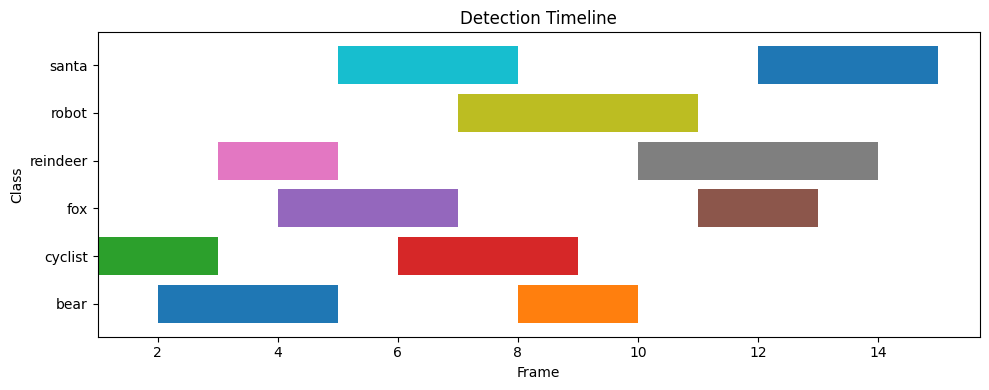

In [3]:
# Uses the functions we built above at the start of the notebook.
segments = build_segments(df, CLASS_NAMES)
gantt_show(segments)

## Creating data using the Camera.

In [4]:
frames, timestamps = collect_frames()


------------------------------
Starting to collect frames...


[0:43:27.852865355] [9168]  INFO Camera camera_manager.cpp:340 libcamera v0.7.0+69-4b6c47bd-dirty (2026-04-09T11:30:57+02)
[0:43:27.884507501] [9169]  INFO RPI pisp.cpp:720 libpisp version v1.3.0 9ba67e6680f0 09-04-2026 (08:21:38)
[0:43:27.887782292] [9169]  INFO IPAProxy ipa_proxy.cpp:180 Using tuning file /usr/local/share/libcamera/ipa/rpi/pisp/imx219.json
[0:43:27.897016745] [9169]  INFO Camera camera_manager.cpp:223 Adding camera '/base/axi/pcie@120000/rp1/i2c@88000/imx219@10' for pipeline handler rpi/pisp
[0:43:27.897049671] [9169]  INFO RPI pisp.cpp:1181 Registered camera /base/axi/pcie@120000/rp1/i2c@88000/imx219@10 to CFE device /dev/media2 and ISP device /dev/media0 using PiSP variant BCM2712_D0
[0:43:27.904463896] [9169]  WARN V4L2 v4l2_pixelformat.cpp:346 Unsupported V4L2 pixel format RPBP
[0:43:27.905899831] [9168]  INFO Camera camera.cpp:1216 configuring streams: (0) 1920x1080-BGR888/sRGB (1) 1920x1080-BGGR_PISP_COMP1/RAW
[0:43:27.906254032] [9169]  INFO RPI pisp.cpp:1485 

Frame 1 captured at 2026-04-20 07:58:06.600827
Frame 2 captured at 2026-04-20 07:58:07.628569
Frame 3 captured at 2026-04-20 07:58:08.640944
Frame 4 captured at 2026-04-20 07:58:09.664055
Frame 5 captured at 2026-04-20 07:58:10.678289
Frame 6 captured at 2026-04-20 07:58:11.691242
Frame 7 captured at 2026-04-20 07:58:12.711029
Frame 8 captured at 2026-04-20 07:58:13.723214
Frame 9 captured at 2026-04-20 07:58:14.743698

Interrupted. 9 frames collected.
Turning off camera...
Camera turned off!


In [5]:
df = predict_frames(frames, timestamps)
df[CLASS_NAMES] = (df[CLASS_NAMES] > THRESHOLD).astype(int)
df

[          0           0           0           0           0           0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Predicting frame number: 1
[          0           0           0           0           0           0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Predicting frame number: 2
[          0           0           0           0           0           0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.4039902985095978]
Predicting frame number: 3
[          0           0           0           0           0           0]
[0.0, 0.0, 0.2546288073062897, 0.0, 0.0, 0.32263511419296265]
Predicting frame number: 4
[          0           0           0           0           0           0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.4096185564994812]
Predicting frame number: 5
[          0           0           0           0           0           0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.5279989838600159]
Predicting frame number: 6
[          0           0           0           0           0           0]
[0.0, 0.0, 0.41024696826934814, 0.0, 0.0, 0.42404690384864

,timestamp,bear,cyclist,fox,reindeer,robot,santa
0,2026-04-20 07:58:06.600827,0,0,0,0,0,0
1,2026-04-20 07:58:07.628569,0,0,0,0,0,0
2,2026-04-20 07:58:08.640944,0,0,0,0,0,1
3,2026-04-20 07:58:09.664055,0,0,0,0,0,1
4,2026-04-20 07:58:10.678289,0,0,0,0,0,1
5,2026-04-20 07:58:11.691242,0,0,0,0,0,1
6,2026-04-20 07:58:12.711029,0,0,1,0,0,1
7,2026-04-20 07:58:13.723214,0,0,1,0,0,0
8,2026-04-20 07:58:14.743698,0,0,1,0,0,0


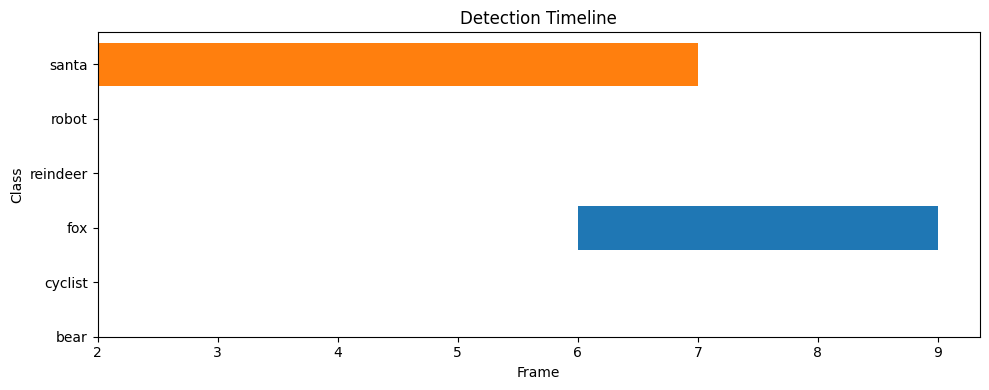

In [6]:
segments = build_segments(df, CLASS_NAMES)
gantt_show(segments)

In [ ]:
df.to_csv("object_log.csv", index=False)